# 01 — Preprocessing: Feature Cleaning

Applies the cleaning decisions from `notebooks/eda/04_features.ipynb` to the raw radiomic
feature matrix and produces a modelling-ready dataset joined with the ISIC diagnosis label.

**Input:** `data/features_features_all_channels.csv` (76,715 × 408 features)  
**Labels:** `results/processed/isic_selected.parquet` → column `target` (4 classes)  
**Output:** `results/processed/features_clean.parquet`

### Cleaning steps (from EDA recommendations)

| # | Step | Rationale |
|---|------|-----------|
| 1 | Replace ±inf → NaN | pyradiomics emits inf on degenerate masks |
| 2 | Impute NaN with column median | preserve rows; radiomic features are skewed |
| 3 | Drop zero-variance columns | carry no information |
| 4 | Winsorize at p1–p99 | mean IQR outlier rate was 6.38% |
| 5 | Correlation filter (\|r\| > 0.95) | 38 redundant pairs within gray channel alone |

> **Not done here (deliberately):** no scaling / standardization, no one-hot encoding.
> Those are fit-on-train transforms and belong inside the modelling pipeline to avoid leakage.

---

## 0. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from src.paths import DATA_DIR, RESULTS_DIR, PROCESSED_DIR, ensure_dir
from src.viz import setup_style, save_fig, CLASS_COLORS

setup_style()

FEATURES_CSV = DATA_DIR / "features_features_all_channels.csv"
METADATA_PQ  = PROCESSED_DIR / "isic_selected.parquet"
OUT_PARQUET  = PROCESSED_DIR / "features_clean.parquet"
OUT_DIR      = ensure_dir(RESULTS_DIR / "eda" / "preprocessing")

LABEL_COL     = "target"
CLINICAL_COLS = ["age_approx", "sex"] + [f"anatom_site_{s}" for s in [
    "Anogenital region", "Head and neck", "Lower extremity",
    "Trunk", "Upper extremity", "unknown",
]]

# Cleaning hyperparameters
WINSOR_LOW, WINSOR_HIGH = 0.01, 0.99
CORR_THRESHOLD          = 0.95

print(f"Features : {FEATURES_CSV}")
print(f"Metadata : {METADATA_PQ}")
print(f"Output   : {OUT_PARQUET}")

Features : /Users/indalecio.rios/Documents/personal-github/scd-ml/data/features_features_all_channels.csv
Metadata : /Users/indalecio.rios/Documents/personal-github/scd-ml/results/processed/isic_selected.parquet
Output   : /Users/indalecio.rios/Documents/personal-github/scd-ml/results/processed/features_clean.parquet


---
## 1. Load features and join labels

In [2]:
feat = pl.read_csv(FEATURES_CSV, infer_schema_length=10_000).to_pandas()
print(f"Raw features   : {feat.shape[0]:,} rows × {feat.shape[1]:,} cols")

meta = pd.read_parquet(METADATA_PQ)
print(f"Metadata       : {meta.shape[0]:,} rows × {meta.shape[1]:,} cols")
print(f"\nLabel '{LABEL_COL}' distribution:")
print(meta[LABEL_COL].value_counts())

Raw features   : 76,715 rows × 409 cols
Metadata       : 76,974 rows × 14 cols

Label 'target' distribution:
target
Benign-melanocytic           48974
Malignant-melanocytic        10669
Benign-non-melanocytic        9585
Malignant-non-melanocytic     7746
Name: count, dtype: int64


In [3]:
# Inner join on image_id ↔ isic_id — keeps only images that have BOTH features and a label
keep_meta = ["isic_id", LABEL_COL] + [c for c in CLINICAL_COLS if c in meta.columns]

df = feat.merge(
    meta[keep_meta].rename(columns={"isic_id": "image_id"}),
    on="image_id",
    how="inner",
)

n_unmatched = len(feat) - len(df)
print(f"Matched rows   : {len(df):,} / {len(feat):,}")
print(f"Unmatched      : {n_unmatched:,} (features with no label — dropped)")
print(f"\nClass distribution after join:")
print(df[LABEL_COL].value_counts())

feature_cols = [c for c in df.columns if "__" in c]
print(f"\nRadiomic feature columns: {len(feature_cols):,}")

Matched rows   : 76,715 / 76,715
Unmatched      : 0 (features with no label — dropped)

Class distribution after join:
target
Benign-melanocytic           48912
Malignant-melanocytic        10610
Benign-non-melanocytic        9559
Malignant-non-melanocytic     7634
Name: count, dtype: int64

Radiomic feature columns: 408


In [4]:
# Sanity check: does the joined subset preserve the original class balance?
comparison = pd.DataFrame({
    "metadata_pct": meta[LABEL_COL].value_counts(normalize=True) * 100,
    "joined_pct":   df[LABEL_COL].value_counts(normalize=True) * 100,
}).round(2)
comparison["drift"] = (comparison["joined_pct"] - comparison["metadata_pct"]).round(2)
comparison

,metadata_pct,joined_pct,drift
target,,,
Benign-melanocytic,63.62,63.76,0.14
Malignant-melanocytic,13.86,13.83,-0.03
Benign-non-melanocytic,12.45,12.46,0.01
Malignant-non-melanocytic,10.06,9.95,-0.11


---
## 2. Replace ±inf → NaN, then impute with column median

In [5]:
X = df[feature_cols]

n_inf_before  = int(np.isinf(X.to_numpy(dtype=float)).sum())
n_null_before = int(X.isna().sum().sum())
print(f"Infinite values : {n_inf_before:,}")
print(f"Null values     : {n_null_before:,}")

X = X.replace([np.inf, -np.inf], np.nan)

medians = X.median()
X = X.fillna(medians)

n_remaining = int(X.isna().sum().sum())
print(f"\nAfter imputation — remaining NaN: {n_remaining:,}")

# Any column that was ENTIRELY NaN can't be imputed — drop it
all_nan_cols = X.columns[X.isna().all()].tolist()
if all_nan_cols:
    print(f"Dropping {len(all_nan_cols)} all-NaN columns: {all_nan_cols}")
    X = X.drop(columns=all_nan_cols)

Infinite values : 0
Null values     : 0

After imputation — remaining NaN: 0


---
## 3. Drop zero-variance columns

In [6]:
stds = X.std()
zero_var_cols = stds[stds == 0].index.tolist()

print(f"Zero-variance columns: {len(zero_var_cols)}")
if zero_var_cols:
    for c in zero_var_cols:
        print(f"  {c}")
    X = X.drop(columns=zero_var_cols)

print(f"\nRemaining features: {X.shape[1]:,}")

Zero-variance columns: 0

Remaining features: 408


---
## 4. Winsorize at p1–p99

Clip extreme values instead of dropping rows — radiomic outliers are often real lesions,
not measurement errors, so we keep the sample and bound its influence.

In [7]:
lower_bounds = X.quantile(WINSOR_LOW)
upper_bounds = X.quantile(WINSOR_HIGH)

n_clipped_low  = int((X < lower_bounds).sum().sum())
n_clipped_high = int((X > upper_bounds).sum().sum())
total_cells    = X.size

X_winsor = X.clip(lower=lower_bounds, upper=upper_bounds, axis=1)

print(f"Winsorization bounds: p{WINSOR_LOW:.0%} – p{WINSOR_HIGH:.0%}")
print(f"Values clipped (low) : {n_clipped_low:,}")
print(f"Values clipped (high): {n_clipped_high:,}")
print(f"Total clipped        : {n_clipped_low + n_clipped_high:,} "
      f"({(n_clipped_low + n_clipped_high) / total_cells:.2%} of all cells)")

Winsorization bounds: p1% – p99%
Values clipped (low) : 308,238
Values clipped (high): 306,393
Total clipped        : 614,631 (1.96% of all cells)


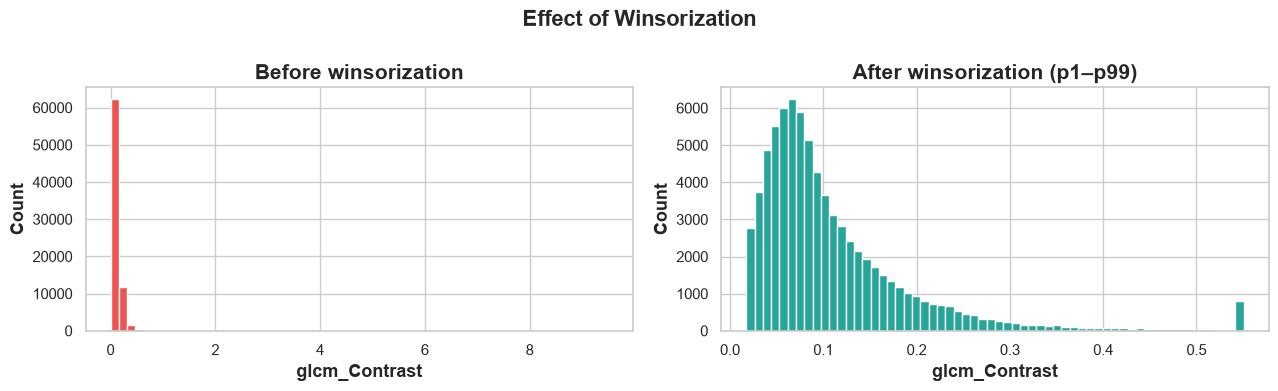

In [8]:
# Visual check: a heavily skewed feature before vs after winsorization
probe = "gray__original_glcm_Contrast"
if probe in X.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].hist(X[probe], bins=60, color="#EF5350", edgecolor="white")
    axes[0].set_title("Before winsorization")
    axes[1].hist(X_winsor[probe], bins=60, color="#26A69A", edgecolor="white")
    axes[1].set_title("After winsorization (p1–p99)")
    for ax in axes:
        ax.set_xlabel(probe.replace("gray__original_", ""))
        ax.set_ylabel("Count")
    fig.suptitle("Effect of Winsorization")
    plt.tight_layout()
    save_fig(fig, OUT_DIR, "01_winsorization_effect")
    plt.show()

X = X_winsor

---
## 5. Correlation filter (|r| > 0.95)

Applied across **all channels at once** — this is where inter-channel redundancy
(blue↔green r≈0.86, and higher for many individual features) actually gets removed.

For each highly-correlated pair we drop the feature with the **higher mean absolute
correlation** to everything else, keeping the more independent one.

In [9]:
corr = X.corr().abs()
mean_abs_corr = corr.mean()

# Upper triangle only — each pair considered once
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = set()
pairs   = []

for col in upper.columns:
    high_corr_partners = upper.index[upper[col] > CORR_THRESHOLD].tolist()
    for row in high_corr_partners:
        if row in to_drop or col in to_drop:
            continue
        # Drop whichever is more redundant overall
        loser = col if mean_abs_corr[col] >= mean_abs_corr[row] else row
        to_drop.add(loser)
        pairs.append({
            "feature_a": row,
            "feature_b": col,
            "r": round(float(upper.loc[row, col]), 4),
            "dropped": loser,
        })

print(f"Highly-correlated pairs (|r| > {CORR_THRESHOLD}): {len(pairs):,}")
print(f"Features dropped                       : {len(to_drop):,}")
print(f"Features retained                      : {X.shape[1] - len(to_drop):,}")

Highly-correlated pairs (|r| > 0.95): 214
Features dropped                       : 214
Features retained                      : 194


In [10]:
pairs_df = pd.DataFrame(pairs).sort_values("r", ascending=False)
print("Top 15 most redundant pairs:")
pairs_df.head(15)

Top 15 most redundant pairs:


,feature_a,feature_b,r,dropped
67,green__original_glcm_JointAverage,green__original_glcm_SumAverage,1.0,green__original_glcm_SumAverage
149,blue__original_shape2D_PixelSurface,gray__original_shape2D_PixelSurface,1.0,gray__original_shape2D_PixelSurface
103,blue__original_shape2D_PixelSurface,red__original_shape2D_PixelSurface,1.0,red__original_shape2D_PixelSurface
102,blue__original_shape2D_PerimeterSurfaceRatio,red__original_shape2D_PerimeterSurfaceRatio,1.0,red__original_shape2D_PerimeterSurfaceRatio
25,blue__original_glcm_Autocorrelation,blue__original_gldm_HighGrayLevelEmphasis,1.0,blue__original_glcm_Autocorrelation
99,blue__original_shape2D_PixelSurface,red__original_shape2D_MeshSurface,1.0,red__original_shape2D_MeshSurface
128,red__original_glcm_Autocorrelation,red__original_gldm_HighGrayLevelEmphasis,1.0,red__original_gldm_HighGrayLevelEmphasis
141,red__original_glszm_LargeAreaEmphasis,red__original_glszm_ZoneVariance,1.0,red__original_glszm_ZoneVariance
97,green__original_shape2D_MajorAxisLength,red__original_shape2D_MajorAxisLength,1.0,red__original_shape2D_MajorAxisLength
142,blue__original_shape2D_Elongation,gray__original_shape2D_Elongation,1.0,gray__original_shape2D_Elongation


In [11]:
X_final = X.drop(columns=list(to_drop))

# How many features survived, per channel and per feature class?
def parse_col(c):
    channel, rest = c.split("__", 1)
    fclass = rest.replace("original_", "").split("_", 1)[0]
    return channel, fclass

survival = pd.DataFrame(
    [{"column": c, "channel": parse_col(c)[0], "class": parse_col(c)[1],
      "kept": c in X_final.columns}
     for c in feature_cols if c in X.columns or c in X_final.columns]
)

pivot_kept = survival[survival["kept"]].pivot_table(
    index="class", columns="channel", values="column", aggfunc="count", fill_value=0
)
print("Features retained by class × channel:")
pivot_kept

Features retained by class × channel:


channel,blue,gray,green,red
class,,,,
firstorder,10,4,10,11
glcm,10,9,6,12
gldm,5,3,5,5
glrlm,9,8,8,12
glszm,12,12,12,11
ngtdm,5,2,3,5
shape2D,4,0,1,0


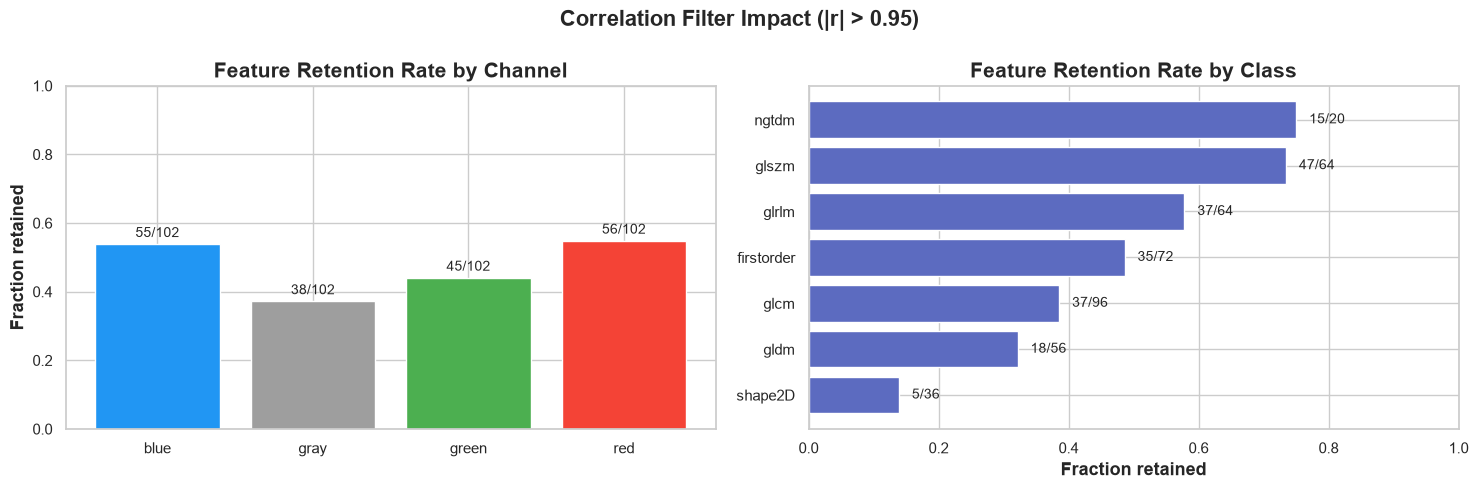

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Retention rate by channel
by_channel = survival.groupby("channel")["kept"].agg(["sum", "count"])
by_channel["rate"] = by_channel["sum"] / by_channel["count"]
ch_colors = {"blue": "#2196F3", "green": "#4CAF50", "red": "#F44336", "gray": "#9E9E9E"}
axes[0].bar(by_channel.index, by_channel["rate"],
            color=[ch_colors[c] for c in by_channel.index])
axes[0].set_title("Feature Retention Rate by Channel")
axes[0].set_ylabel("Fraction retained")
axes[0].set_ylim(0, 1)
for i, (idx, row) in enumerate(by_channel.iterrows()):
    axes[0].text(i, row["rate"] + 0.02, f"{int(row['sum'])}/{int(row['count'])}",
                 ha="center", fontsize=10)

# Retention rate by feature class
by_class = survival.groupby("class")["kept"].agg(["sum", "count"])
by_class["rate"] = by_class["sum"] / by_class["count"]
by_class = by_class.sort_values("rate")
axes[1].barh(by_class.index, by_class["rate"], color="#5C6BC0")
axes[1].set_title("Feature Retention Rate by Class")
axes[1].set_xlabel("Fraction retained")
axes[1].set_xlim(0, 1)
for i, (idx, row) in enumerate(by_class.iterrows()):
    axes[1].text(row["rate"] + 0.02, i, f"{int(row['sum'])}/{int(row['count'])}",
                 va="center", fontsize=10)

fig.suptitle(f"Correlation Filter Impact (|r| > {CORR_THRESHOLD})")
plt.tight_layout()
save_fig(fig, OUT_DIR, "02_correlation_filter_retention")
plt.show()

---
## 6. Assemble and export

In [13]:
clinical_present = [c for c in CLINICAL_COLS if c in df.columns]

clean = pd.concat(
    [
        df[["image_id"]].reset_index(drop=True),
        X_final.reset_index(drop=True),
        df[clinical_present].reset_index(drop=True),
        df[[LABEL_COL]].reset_index(drop=True),
    ],
    axis=1,
)

print(f"Final shape: {clean.shape[0]:,} rows × {clean.shape[1]:,} cols")
print(f"  image_id          : 1")
print(f"  radiomic features : {X_final.shape[1]:,}")
print(f"  clinical metadata : {len(clinical_present)}")
print(f"  label ({LABEL_COL})     : 1")
print()
print(f"Remaining NaN : {int(clean.isna().sum().sum()):,}")
print(f"Remaining inf : {int(np.isinf(clean[X_final.columns].to_numpy(dtype=float)).sum()):,}")

Final shape: 76,715 rows × 204 cols
  image_id          : 1
  radiomic features : 194
  clinical metadata : 8
  label (target)     : 1

Remaining NaN : 0
Remaining inf : 0


In [14]:
ensure_dir(PROCESSED_DIR)
clean.to_parquet(OUT_PARQUET, compression="snappy", index=False)

size_mb = OUT_PARQUET.stat().st_size / 1024**2
print(f"Saved {OUT_PARQUET}  ({size_mb:.1f} MB)")

# Persist the dropped-feature manifest so the decision is auditable/reproducible
manifest = PROCESSED_DIR / "features_dropped.csv"
pd.DataFrame({
    "dropped_feature": sorted(to_drop | set(zero_var_cols) | set(all_nan_cols)),
}).assign(
    reason=lambda d: d["dropped_feature"].map(
        lambda c: "zero_variance" if c in zero_var_cols
        else "all_nan" if c in all_nan_cols
        else f"corr>{CORR_THRESHOLD}"
    )
).to_csv(manifest, index=False)
print(f"Saved {manifest}")

Saved /Users/indalecio.rios/Documents/personal-github/scd-ml/results/processed/features_clean.parquet  (127.1 MB)
Saved /Users/indalecio.rios/Documents/personal-github/scd-ml/results/processed/features_dropped.csv


---
## 7. Summary

In [15]:
summary = pd.DataFrame([
    {"Step": "Raw features",              "Features": len(feature_cols), "Rows": len(feat)},
    {"Step": "After label join",          "Features": len(feature_cols), "Rows": len(df)},
    {"Step": "After all-NaN drop",        "Features": len(feature_cols) - len(all_nan_cols), "Rows": len(df)},
    {"Step": "After zero-variance drop",  "Features": len(feature_cols) - len(all_nan_cols) - len(zero_var_cols), "Rows": len(df)},
    {"Step": "After correlation filter",  "Features": X_final.shape[1], "Rows": len(df)},
])
summary["Reduction"] = (
    (1 - summary["Features"] / len(feature_cols)) * 100
).round(1).astype(str) + "%"
summary

,Step,Features,Rows,Reduction
0,Raw features,408,76715,0.0%
1,After label join,408,76715,0.0%
2,After all-NaN drop,408,76715,0.0%
3,After zero-variance drop,408,76715,0.0%
4,After correlation filter,194,76715,52.5%


In [16]:
print("=" * 64)
print("PREPROCESSING COMPLETE")
print(f"  Input      : {len(feat):,} images × {len(feature_cols):,} features")
print(f"  Output     : {len(clean):,} images × {X_final.shape[1]:,} features + {len(clinical_present)} clinical + label")
print(f"  Reduction  : {(1 - X_final.shape[1] / len(feature_cols)):.1%} of radiomic features removed")
print(f"  Saved to   : {OUT_PARQUET}")
print()
print("  NOT applied (belongs in the modelling pipeline, fit on train only):")
print("    · Scaling / standardization")
print("    · One-hot encoding of `sex`")
print("    · Class-imbalance handling")
print("=" * 64)

PREPROCESSING COMPLETE
  Input      : 76,715 images × 408 features
  Output     : 76,715 images × 194 features + 8 clinical + label
  Reduction  : 52.5% of radiomic features removed
  Saved to   : /Users/indalecio.rios/Documents/personal-github/scd-ml/results/processed/features_clean.parquet

  NOT applied (belongs in the modelling pipeline, fit on train only):
    · Scaling / standardization
    · One-hot encoding of `sex`
    · Class-imbalance handling
